In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import requests
import warnings
warnings.filterwarnings("ignore")

from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

diabetes = pd.read_csv(url, names=columns)

print(diabetes.shape)
print(diabetes.head())


(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
print(diabetes.isnull().sum())

zero_columns = [
    "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI"
]

print((diabetes[zero_columns] == 0).sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [4]:
for col in zero_columns:
    diabetes[col] = diabetes[col].replace(0, np.nan)

print(diabetes.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [5]:
for col in zero_columns:
    diabetes[col] = diabetes[col].fillna(diabetes[col].median())

print(diabetes.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
print(diabetes.describe())
print(diabetes["Outcome"].value_counts())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.455208                  0.471876   33.240885    0.348958  
std      6.875177                  0.331329   11.760232    0.476951  
min     18.200000                  

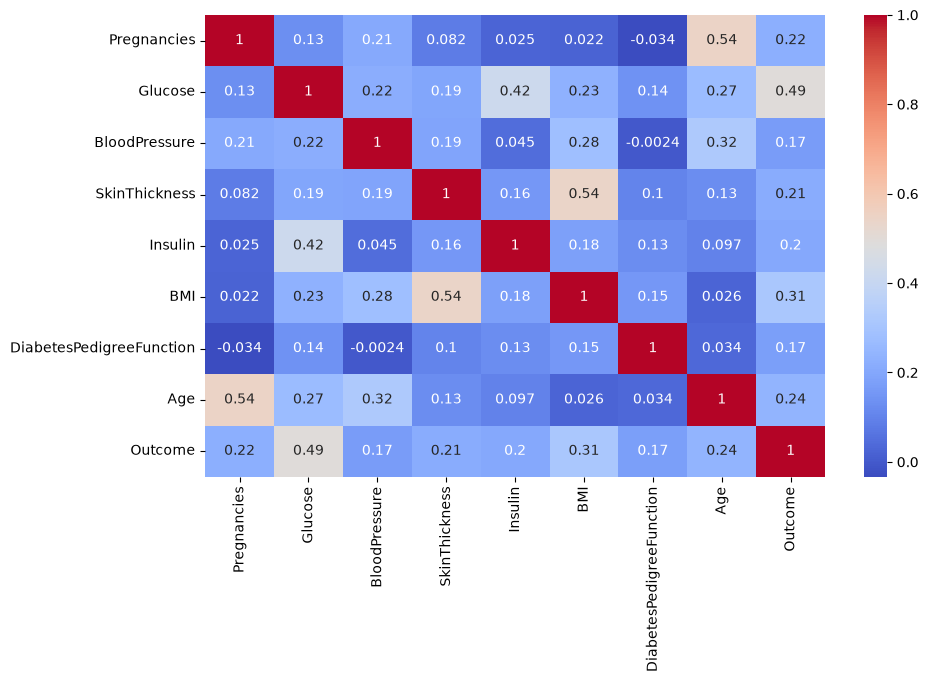

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(diabetes.corr(), annot=True, cmap="coolwarm")
plt.show()

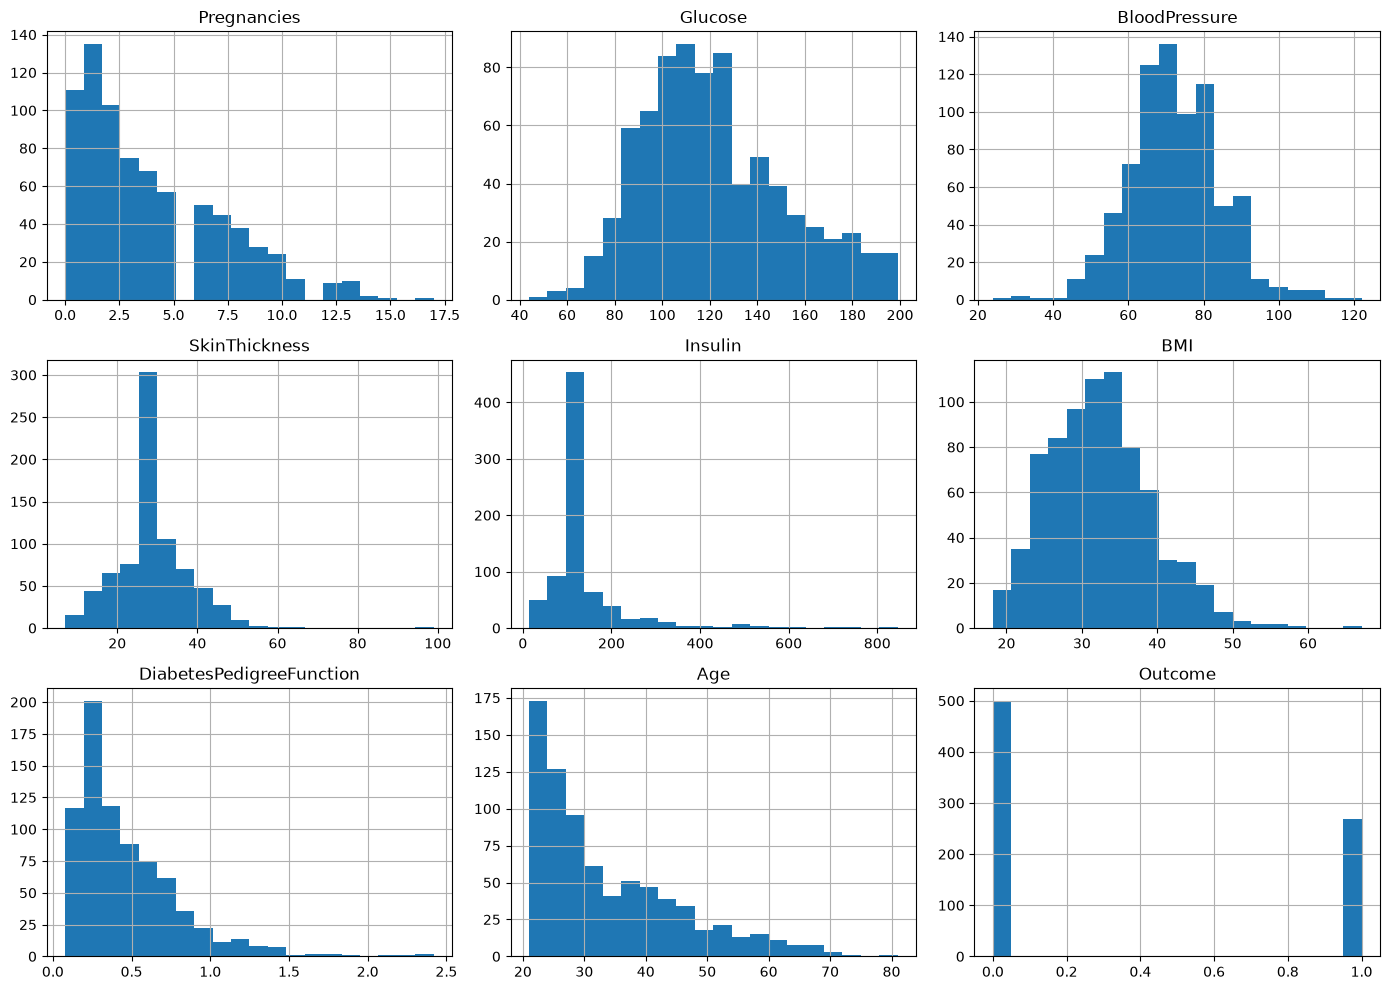

In [8]:
diabetes.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

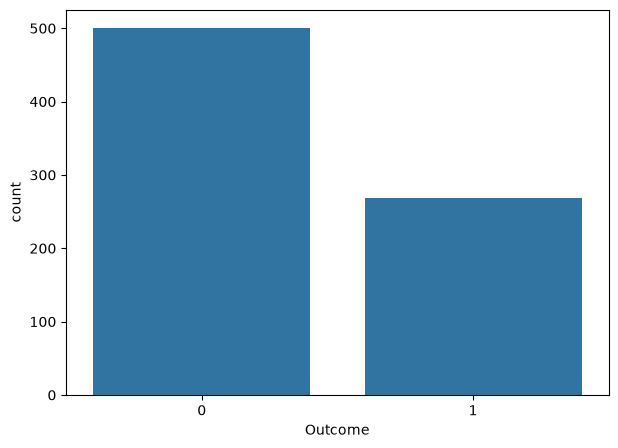

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Outcome", data=diabetes)
plt.show()

In [10]:
diabetes["BMI_Category"] = pd.cut(
    diabetes["BMI"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

diabetes["Age_Group"] = pd.cut(
    diabetes["Age"],
    bins=[0, 30, 50, np.inf],
    labels=["Young", "Middle", "Older"]
)

print(diabetes.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome BMI_Category Age_Group  
0                     0.627   50        1        Obese    Middle  
1                     0.351   31        0   Overweight    Middle  
2                     0.672   32        1       Normal    Middle  
3                     0.167   21        0   Overweight     Young  
4                     2.288   33        1        Obese    Middle  


In [11]:
diabetic = diabetes[diabetes["Outcome"] == 1]["Glucose"]
non_diabetic = diabetes[diabetes["Outcome"] == 0]["Glucose"]

t_stat, p_value = stats.ttest_ind(diabetic, non_diabetic, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Glucose levels differ significantly between the two groups.")
else:
    print("Fail to reject H0: No significant difference found.")

T-statistic: 14.852653441079662
P-value: 3.542148561443004e-41
Reject H0: Glucose levels differ significantly between the two groups.


In [12]:
contingency_table = pd.crosstab(
    diabetes["BMI_Category"],
    diabetes["Outcome"]
)

print(contingency_table)

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2_stat)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Reject H0: BMI category and diabetes outcome are significantly associated.")
else:
    print("Fail to reject H0.")

Outcome         0    1
BMI_Category          
Underweight     4    0
Normal        101    7
Overweight    136   44
Obese         259  217
Chi-square statistic: 73.13331881767633
P-value: 9.10165626851089e-16
Degrees of freedom: 3
Reject H0: BMI category and diabetes outcome are significantly associated.


In [13]:
groups = [
    diabetes[diabetes["Age_Group"] == group]["Glucose"]
    for group in diabetes["Age_Group"].dropna().unique()
]

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Mean glucose levels differ significantly between age groups.")
else:
    print("Fail to reject H0.")

F-statistic: 29.597220170305267
P-value: 4.1605055255643914e-13
Reject H0: Mean glucose levels differ significantly between age groups.


In [14]:
X = diabetes[
    [
        "Pregnancies", "Glucose", "BloodPressure",
        "SkinThickness", "Insulin", "BMI",
        "DiabetesPedigreeFunction", "Age"
    ]
]

y = diabetes["Outcome"]

X_positive = X - X.min()

selector = SelectKBest(score_func=chi2, k=5)
X_selected = selector.fit_transform(X_positive, y)

selected_features = X.columns[selector.get_support()]

print("Selected features:")
print(selected_features)

Selected features:
Index(['Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age'], dtype='str')


In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.63994726  0.86604475 -0.03198993  0.67064253 -0.18154124  0.16661938
   0.46849198  1.4259954 ]
 [-0.84488505 -1.20506583 -0.5283186  -0.01230129 -0.18154124 -0.85219976
  -0.36506078 -0.19067191]
 [ 1.23388019  2.01666174 -0.69376149 -0.01230129 -0.18154124 -1.33250021
   0.60439732 -0.10558415]
 [-0.84488505 -1.07356674 -0.5283186  -0.69524511 -0.54064177 -0.63388137
  -0.92076261 -1.04154944]
 [-1.14185152  0.50442227 -2.67907616  0.67064253  0.31656594  1.5493025
   5.4849091  -0.0204964 ]]


In [16]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

text_df = pd.read_csv("mtsamples.csv")

print(text_df.shape)
print(text_df.head())
print(text_df.columns)

(4999, 6)
   Unnamed: 0                                        description  \
0           0   A 23-year-old white female presents with comp...   
1           1           Consult for laparoscopic gastric bypass.   
2           2           Consult for laparoscopic gastric bypass.   
3           3                             2-D M-Mode. Doppler.     
4           4                                 2-D Echocardiogram   

             medical_specialty                                sample_name  \
0         Allergy / Immunology                         Allergic Rhinitis    
1                   Bariatrics   Laparoscopic Gastric Bypass Consult - 2    
2                   Bariatrics   Laparoscopic Gastric Bypass Consult - 1    
3   Cardiovascular / Pulmonary                    2-D Echocardiogram - 1    
4   Cardiovascular / Pulmonary                    2-D Echocardiogram - 2    

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   
1  PAS

In [17]:
print(text_df.info())
print(text_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         4999 non-null   int64
 1   description        4999 non-null   str  
 2   medical_specialty  4999 non-null   str  
 3   sample_name        4999 non-null   str  
 4   transcription      4966 non-null   str  
 5   keywords           3931 non-null   str  
dtypes: int64(1), str(5)
memory usage: 234.5 KB
None
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


In [18]:
print(text_df.describe(include="all"))

         Unnamed: 0                                        description  \
count   4999.000000                                               4999   
unique          NaN                                               2348   
top             NaN   An example/template for a routine normal male...   
freq            NaN                                                 12   
mean    2499.000000                                                NaN   
std     1443.231328                                                NaN   
min        0.000000                                                NaN   
25%     1249.500000                                                NaN   
50%     2499.000000                                                NaN   
75%     3748.500000                                                NaN   
max     4998.000000                                                NaN   

       medical_specialty         sample_name  \
count               4999                4999   
unique         

In [19]:
print(text_df.columns.tolist())

['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


In [20]:
text_df = text_df.dropna(
    subset=["transcription"]
).reset_index(drop=True)

print(text_df.shape)

(4966, 6)


In [21]:
def remove_phi(text):
    text = str(text)
    
    text = re.sub(
        r'\b[\w\.-]+@[\w\.-]+\.\w+\b',
        '[EMAIL]',
        text
    )
    
    text = re.sub(
        r'\b\d{3}[-.\s]\d{2}[-.\s]\d{4}\b',
        '[ID]',
        text
    )
    
    text = re.sub(
        r'\b\d{10}\b',
        '[PHONE]',
        text
    )
    
    text = re.sub(
        r'\b(?:mr|mrs|ms|dr)\.?\s+[A-Z][a-z]+\b',
        '[NAME]',
        text,
        flags=re.I
    )
    
    return text

text_df["clean_text"] = text_df["transcription"].apply(remove_phi)

print(text_df[["transcription", "clean_text"]].head())

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   
1  PAST MEDICAL HISTORY:, He has difficulty climb...   
2  HISTORY OF PRESENT ILLNESS: , I have seen ABC ...   
3  2-D M-MODE: , ,1.  Left atrial enlargement wit...   
4  1.  The left ventricular cavity size and wall ...   

                                          clean_text  
0  SUBJECTIVE:,  This 23-year-old white female pr...  
1  PAST MEDICAL HISTORY:, He has difficulty climb...  
2  HISTORY OF PRESENT ILLNESS: , I have seen ABC ...  
3  2-D M-MODE: , ,1.  Left atrial enlargement wit...  
4  1.  The left ventricular cavity size and wall ...  


In [22]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(
        r'\[email\]|\[id\]|\[phone\]|\[name\]',
        ' ',
        text
    )
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

text_df["clean_text"] = text_df["clean_text"].apply(clean_text)

print(text_df["clean_text"].head())

0    subjective this year old white female presents...
1    past medical history he has difficulty climbin...
2    history of present illness i have seen abc tod...
3    d m mode left atrial enlargement with left atr...
4    the left ventricular cavity size and wall thic...
Name: clean_text, dtype: str


In [23]:
text_df["word_count"] = text_df["clean_text"].apply(
    lambda x: len(x.split())
)

text_df["char_count"] = text_df["clean_text"].apply(len)

print(text_df[["word_count", "char_count"]].describe())

        word_count    char_count
count  4966.000000   4966.000000
mean    466.968788   2878.635723
std     315.420679   1897.298548
min       1.000000      9.000000
25%     244.000000   1509.000000
50%     402.000000   2496.500000
75%     617.750000   3791.500000
max    2959.000000  17378.000000


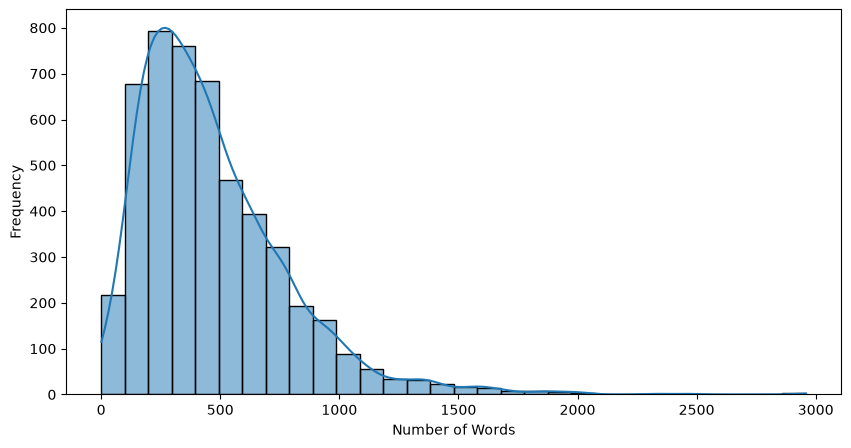

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    text_df["word_count"],
    bins=30,
    kde=True
)

plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

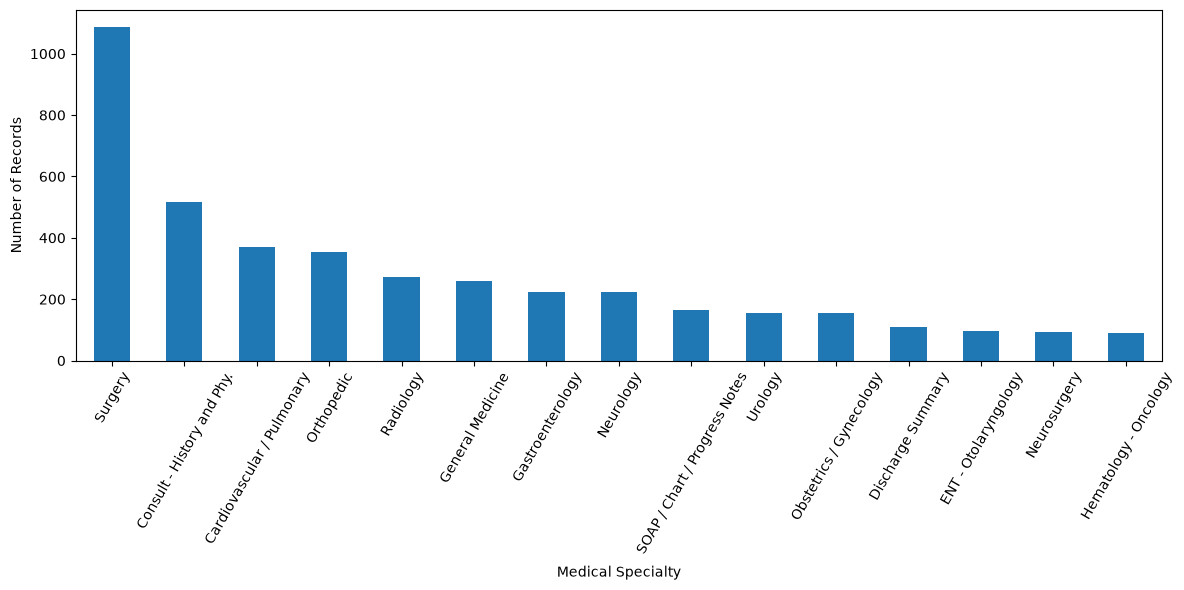

In [25]:
if "medical_specialty" in text_df.columns:
    plt.figure(figsize=(12, 6))
    
    text_df["medical_specialty"].value_counts().head(15).plot(
        kind="bar"
    )
    
    plt.xlabel("Medical Specialty")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()

In [26]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(
    num_words=5000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(text_df["clean_text"])

sequences = tokenizer.texts_to_sequences(
    text_df["clean_text"]
)

padded_sequences = pad_sequences(
    sequences,
    maxlen=100,
    padding="post",
    truncating="post"
)

print("Vocabulary size:", len(tokenizer.word_index))
print("Padded shape:", padded_sequences.shape)
print(padded_sequences[:2])

Vocabulary size: 20928
Padded shape: (4966, 100)
[[1102   18   71   73  282  195  635    8  469    5  198   13   69    6
    48  198  203   13    1    9    1   56   13 2860  248   41  990  625
     9    2   85   13   23 1836 3639    3 3503  126 1625   14  783   55
    56   20 1800    6 3774    1   13   23   69 3690   54   13   69   26
   244    1    3   13  752   58   46  208   90  253  290   46  102   36
   744    6   32 1333  148   38   13   23   69   83    2 2637    1   56
    12 1207  324    1   13  102   48 1307   56    1   36 1735  156  566
    14   18]
 [  85  117   29   15   23  232    1 3456  232    8    1    1 4623 4934
    69    6    1    1    3 2441 3062  222    2 1109   15 3063  249  390
     7  357   19  242    3  102    1   15   23  232 1318   90 4694   25
   771    1    5 3456  232    8 3137   15   23  193    3  241 2210  295
   231   42   82   42  246    3  494   42    3  447   15   23 1843 1126
    84   85  184   29 1844    1  125   17   31   21  573  209  290  313
  

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

X_text = tfidf.fit_transform(
    text_df["clean_text"]
)

print("TF-IDF shape:", X_text.shape)

TF-IDF shape: (4966, 1000)


In [28]:
tfidf_features = pd.DataFrame(
    X_text.toarray(),
    columns=tfidf.get_feature_names_out()
)

print(tfidf_features.head())

   abcd   abdomen  abdominal      able  abnormal  abnormalities  abscess  \
0   0.0  0.000000        0.0  0.000000   0.00000       0.000000      0.0   
1   0.0  0.000000        0.0  0.000000   0.00000       0.000000      0.0   
2   0.0  0.031512        0.0  0.042346   0.00000       0.000000      0.0   
3   0.0  0.000000        0.0  0.000000   0.00000       0.000000      0.0   
4   0.0  0.000000        0.0  0.000000   0.06108       0.063727      0.0   

   abuse  achieved  active  ...  wire  withdrawn  woman  work    workup  \
0    0.0       0.0     0.0  ...   0.0        0.0    0.0   0.0  0.000000   
1    0.0       0.0     0.0  ...   0.0        0.0    0.0   0.0  0.000000   
2    0.0       0.0     0.0  ...   0.0        0.0    0.0   0.0  0.057988   
3    0.0       0.0     0.0  ...   0.0        0.0    0.0   0.0  0.000000   
4    0.0       0.0     0.0  ...   0.0        0.0    0.0   0.0  0.000000   

      worse  wound  wrist      year     years  
0  0.134756    0.0    0.0  0.055368  0.00000

In [29]:
print("Number of documents:", X_text.shape[0])
print("Number of TF-IDF features:", X_text.shape[1])
print("Vocabulary size:", len(tokenizer.word_index))
print("Average words per document:", text_df["word_count"].mean())

Number of documents: 4966
Number of TF-IDF features: 1000
Vocabulary size: 20928
Average words per document: 466.9687877567459


In [30]:
text_df.to_csv(
    "processed_medical_transcriptions.csv",
    index=False
)

np.save(
    "text_tfidf_features.npy",
    X_text.toarray()
)

np.save(
    "text_token_sequences.npy",
    padded_sequences
)

print("Text preprocessing completed successfully.")

Text preprocessing completed successfully.


In [31]:
import kagglehub
import os

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Dataset path:", path)
print(os.listdir(path))

Dataset path: /Users/harshilagrawal/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
['chest_xray']


In [32]:
import glob

normal_files = glob.glob(
    os.path.join(path, "**", "NORMAL", "*.jpeg"),
    recursive=True
)

pneumonia_files = glob.glob(
    os.path.join(path, "**", "PNEUMONIA", "*.jpeg"),
    recursive=True
)

print("Normal images:", len(normal_files))
print("Pneumonia images:", len(pneumonia_files))

Normal images: 3166
Pneumonia images: 8546


In [33]:
from PIL import Image

normal_image = Image.open(normal_files[0]).convert("L")
pneumonia_image = Image.open(pneumonia_files[0]).convert("L")

print("Normal image size:", normal_image.size)
print("Pneumonia image size:", pneumonia_image.size)

Normal image size: (1949, 1632)
Pneumonia image size: (1120, 808)


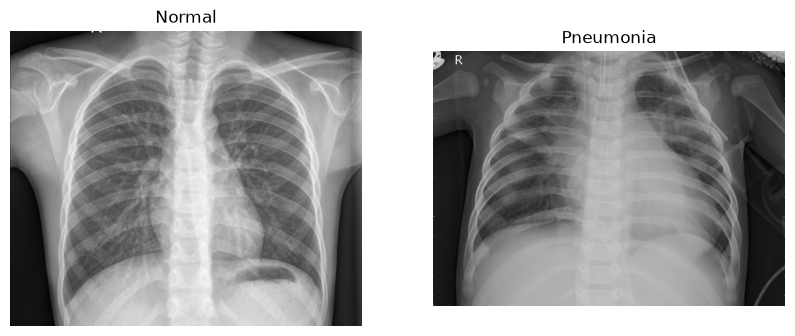

In [34]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(normal_image, cmap="gray")
plt.title("Normal")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pneumonia_image, cmap="gray")
plt.title("Pneumonia")
plt.axis("off")

plt.show()

In [35]:
IMG_SIZE = (224, 224)

normal_array = np.array(normal_image.resize(IMG_SIZE))
pneumonia_array = np.array(pneumonia_image.resize(IMG_SIZE))

normal_array = normal_array / 255.0
pneumonia_array = pneumonia_array / 255.0

print(normal_array.shape)
print(normal_array.min(), normal_array.max())

(224, 224)
0.01568627450980392 0.9764705882352941


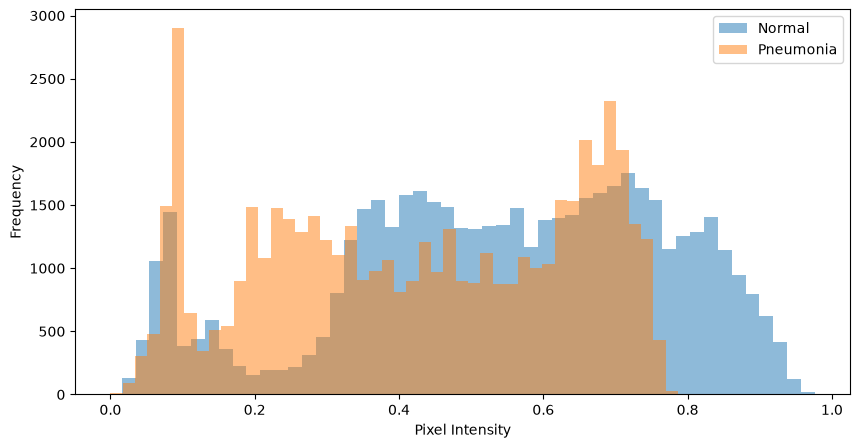

In [36]:
plt.figure(figsize=(10, 5))

plt.hist(normal_array.flatten(), bins=50, alpha=0.5, label="Normal")
plt.hist(pneumonia_array.flatten(), bins=50, alpha=0.5, label="Pneumonia")

plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

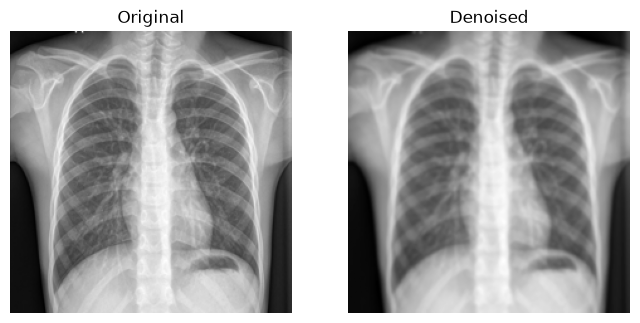

In [37]:
import cv2

normal_uint8 = (normal_array * 255).astype(np.uint8)

denoised_image = cv2.GaussianBlur(
    normal_uint8,
    (5, 5),
    0
)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(normal_uint8, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(denoised_image, cmap="gray")
plt.title("Denoised")
plt.axis("off")

plt.show()

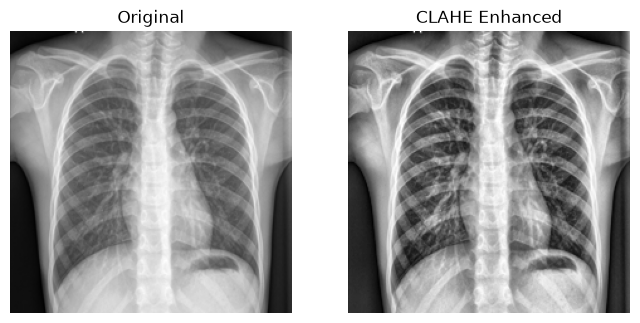

In [38]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

enhanced_image = clahe.apply(normal_uint8)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(normal_uint8, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced_image, cmap="gray")
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.show()

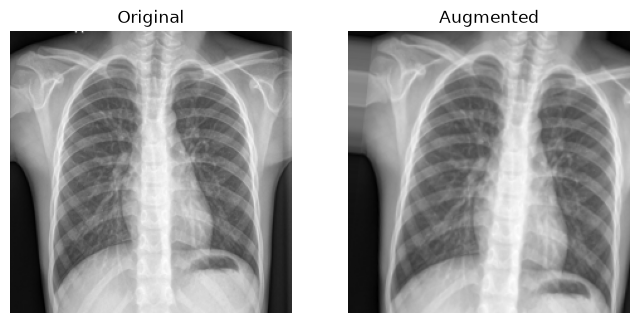

In [39]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

image_input = normal_array.reshape(1, 224, 224, 1)

augmented = datagen.flow(
    image_input,
    batch_size=1
)

augmented_image = next(augmented)[0].reshape(224, 224)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(normal_array, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented_image, cmap="gray")
plt.title("Augmented")
plt.axis("off")

plt.show()

In [40]:
def load_images(files, label, max_images=20):
    images = []
    labels = []

    for file in files[:max_images]:
        try:
            image = Image.open(file).convert("L")
            image = image.resize(IMG_SIZE)
            image = np.array(image) / 255.0

            images.append(image)
            labels.append(label)
        except:
            pass

    return np.array(images), np.array(labels)

normal_images, normal_labels = load_images(
    normal_files,
    0,
    20
)

pneumonia_images, pneumonia_labels = load_images(
    pneumonia_files,
    1,
    20
)

X_images = np.concatenate([
    normal_images,
    pneumonia_images
])

y_images = np.concatenate([
    normal_labels,
    pneumonia_labels
])

print(X_images.shape)
print(y_images.shape)

(40, 224, 224)
(40,)


In [41]:
X_image_flat = X_images.reshape(len(X_images), -1)

n_components = min(40, X_image_flat.shape[0], X_image_flat.shape[1])

pca = PCA(n_components=n_components)

X_image_features = pca.fit_transform(X_image_flat)

print("Original shape:", X_image_flat.shape)
print("Feature shape:", X_image_features.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original shape: (40, 50176)
Feature shape: (40, 40)
Explained variance: 1.0


In [42]:
image_metadata = pd.DataFrame({
    "PatientID": ["P001", "P002", "P003"],
    "Name": ["Patient A", "Patient B", "Patient C"],
    "Age": [4, 5, 3],
    "ImageType": ["X-Ray", "X-Ray", "X-Ray"]
})

print(image_metadata)

image_metadata = image_metadata.drop(
    columns=["PatientID", "Name"]
)

print(image_metadata)

  PatientID       Name  Age ImageType
0      P001  Patient A    4     X-Ray
1      P002  Patient B    5     X-Ray
2      P003  Patient C    3     X-Ray
   Age ImageType
0    4     X-Ray
1    5     X-Ray
2    3     X-Ray


In [43]:
ecg_url = "https://raw.githubusercontent.com/dhiah-dev/Dataset-Compiled-ECG-MIT-BIH-Arrhythmia/main/Compiled-ECG-MIT-BIH-Arrhytmia.csv"

ecg = pd.read_csv(ecg_url)

print("Dataset shape:", ecg.shape)
print(ecg.head())

Dataset shape: (500, 3601)
       0      1      2      3      4      5      6      7      8      9  ...  \
0 -0.390 -0.395 -0.390 -0.405 -0.405 -0.400 -0.375 -0.380 -0.390 -0.395  ...   
1 -0.405 -0.410 -0.410 -0.410 -0.410 -0.400 -0.385 -0.370 -0.375 -0.360  ...   
2 -0.385 -0.365 -0.375 -0.380 -0.390 -0.385 -0.375 -0.360 -0.370 -0.380  ...   
3 -0.360 -0.360 -0.360 -0.360 -0.380 -0.390 -0.395 -0.375 -0.405 -0.450  ...   
4 -0.450 -0.445 -0.450 -0.455 -0.445 -0.450 -0.440 -0.430 -0.415 -0.425  ...   

    3591   3592   3593   3594   3595   3596   3597   3598   3599  label  
0 -0.405 -0.415 -0.405 -0.405 -0.405 -0.410 -0.425 -0.430 -0.420      N  
1 -0.380 -0.390 -0.375 -0.365 -0.365 -0.375 -0.375 -0.385 -0.385      N  
2 -0.360 -0.375 -0.370 -0.370 -0.360 -0.365 -0.375 -0.380 -0.385      N  
3 -0.415 -0.440 -0.445 -0.435 -0.425 -0.430 -0.440 -0.465 -0.460      N  
4 -0.220 -0.225 -0.235 -0.220 -0.220 -0.210 -0.230 -0.245 -0.245      N  

[5 rows x 3601 columns]


In [44]:
print(ecg.info())

print("\nMissing values:")
print(ecg.isnull().sum())

print("\nLast columns:")
print(ecg.columns.tolist()[-10:])

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Columns: 3601 entries, 0 to label
dtypes: float64(3600), str(1)
memory usage: 13.7 MB
None

Missing values:
0        0
1        0
2        0
3        0
4        0
        ..
3596     0
3597     0
3598     0
3599     0
label    0
Length: 3601, dtype: int64

Last columns:
['3591', '3592', '3593', '3594', '3595', '3596', '3597', '3598', '3599', 'label']


In [45]:
label_column = ecg.columns[-1]

X_ecg = ecg.drop(columns=[label_column])
y_ecg = ecg[label_column]

X_ecg = X_ecg.apply(pd.to_numeric, errors="coerce")
X_ecg = X_ecg.fillna(X_ecg.median())

print("Signal data shape:", X_ecg.shape)

print("\nECG class distribution:")
print(y_ecg.value_counts())

Signal data shape: (500, 3600)

ECG class distribution:
label
N    100
S    100
V    100
F    100
Q    100
Name: count, dtype: int64


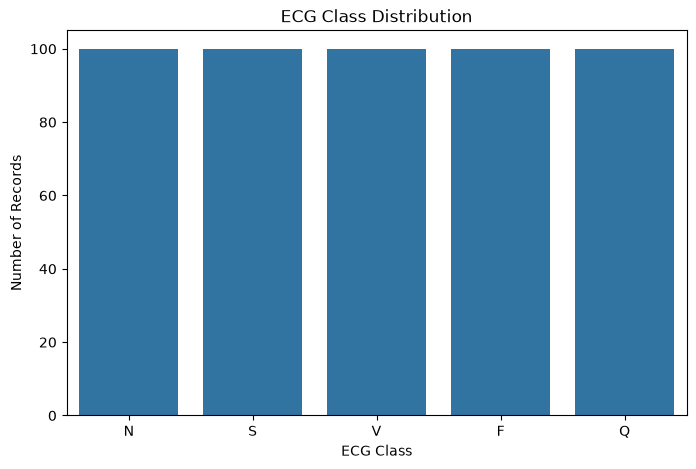

In [46]:
plt.figure(figsize=(8, 5))

sns.countplot(x=y_ecg)

plt.xlabel("ECG Class")
plt.ylabel("Number of Records")
plt.title("ECG Class Distribution")

plt.show()

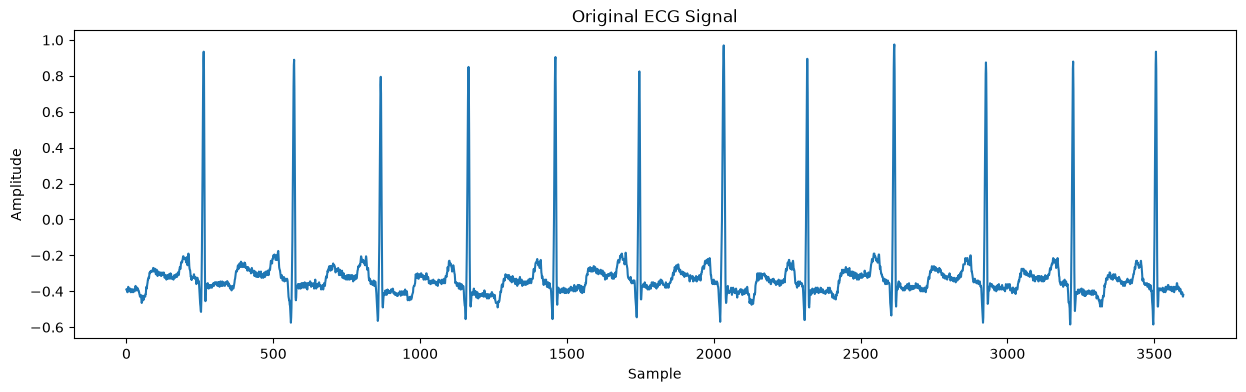

In [47]:
signal = X_ecg.iloc[0].values.astype(float)

plt.figure(figsize=(15, 4))

plt.plot(signal)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Original ECG Signal")

plt.show()

In [48]:
from scipy.signal import butter, filtfilt

def lowpass_filter(signal, cutoff=40, fs=360, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(
        order,
        normal_cutoff,
        btype="low"
    )

    return filtfilt(b, a, signal)

In [49]:
X_ecg_filtered = np.zeros_like(
    X_ecg.values,
    dtype=float
)

for i in range(len(X_ecg)):
    X_ecg_filtered[i] = lowpass_filter(
        X_ecg.iloc[i].values.astype(float)
    )

print("Filtered ECG shape:", X_ecg_filtered.shape)

Filtered ECG shape: (500, 3600)


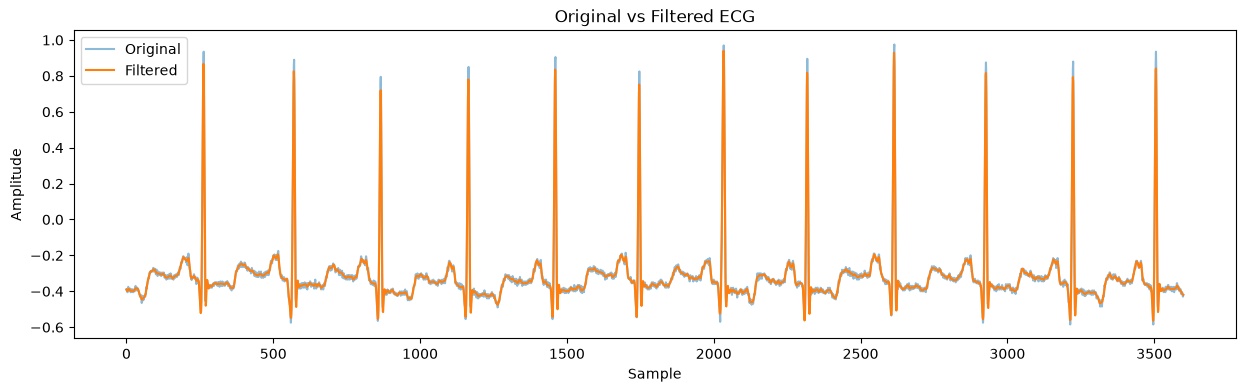

In [50]:
plt.figure(figsize=(15, 4))

plt.plot(
    X_ecg.iloc[0].values,
    alpha=0.5,
    label="Original"
)

plt.plot(
    X_ecg_filtered[0],
    label="Filtered"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Original vs Filtered ECG")

plt.legend()

plt.show()

In [51]:
scaler_ecg = StandardScaler()

X_ecg_scaled = scaler_ecg.fit_transform(
    X_ecg_filtered
)

print("Scaled ECG shape:", X_ecg_scaled.shape)
print("Mean:", X_ecg_scaled[0].mean())
print("Standard deviation:", X_ecg_scaled[0].std())

Scaled ECG shape: (500, 3600)
Mean: -0.015208354677143019
Standard deviation: 0.46201713476532563


In [52]:
window_size = 360

X_ecg_windows = []
y_ecg_windows = []

for i in range(len(X_ecg_filtered)):
    signal = X_ecg_filtered[i]

    for start in range(
        0,
        len(signal) - window_size + 1,
        window_size
    ):
        window = signal[
            start:start + window_size
        ]

        X_ecg_windows.append(window)
        y_ecg_windows.append(y_ecg.iloc[i])

X_ecg_windows = np.array(X_ecg_windows)
y_ecg_windows = np.array(y_ecg_windows)

print("Windowed ECG shape:", X_ecg_windows.shape)
print("Window labels shape:", y_ecg_windows.shape)

Windowed ECG shape: (5000, 360)
Window labels shape: (5000,)


In [53]:
np.random.seed(42)

noise = np.random.normal(
    0,
    0.01,
    size=X_ecg_windows.shape
)

X_ecg_augmented = X_ecg_windows + noise

print("Augmented ECG shape:", X_ecg_augmented.shape)

Augmented ECG shape: (5000, 360)


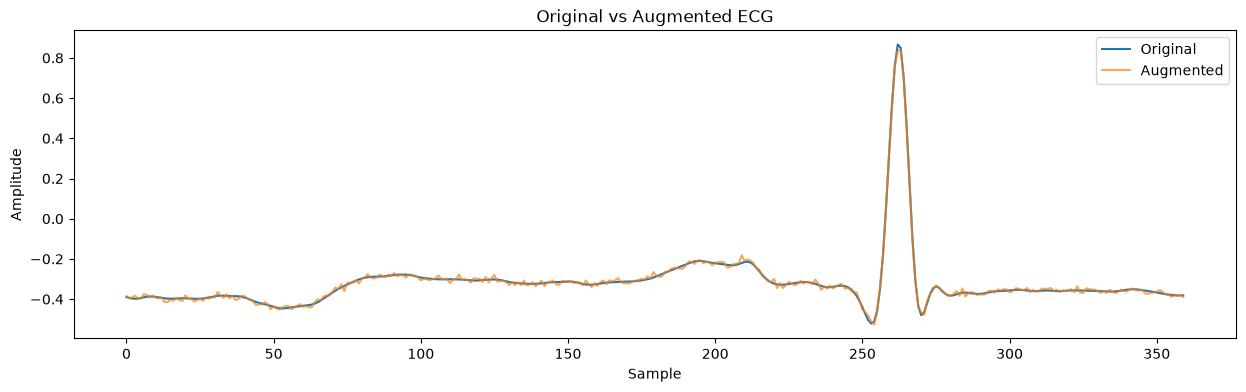

In [54]:
plt.figure(figsize=(15, 4))

plt.plot(
    X_ecg_windows[0],
    label="Original"
)

plt.plot(
    X_ecg_augmented[0],
    alpha=0.7,
    label="Augmented"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Original vs Augmented ECG")

plt.legend()

plt.show()

In [55]:
ecg_features = pd.DataFrame({
    "Mean": X_ecg_filtered.mean(axis=1),
    "Std": X_ecg_filtered.std(axis=1),
    "Min": X_ecg_filtered.min(axis=1),
    "Max": X_ecg_filtered.max(axis=1),
    "Range": X_ecg_filtered.max(axis=1) - X_ecg_filtered.min(axis=1),
    "Median": np.median(X_ecg_filtered, axis=1)
})

print(ecg_features.head())
print("Feature shape:", ecg_features.shape)

       Mean       Std       Min       Max     Range    Median
0 -0.318405  0.163970 -0.563700  0.939803  1.503504 -0.344569
1 -0.367766  0.176339 -0.677703  1.030648  1.708351 -0.390211
2 -0.368657  0.169015 -0.664984  0.979593  1.644578 -0.393676
3 -0.344692  0.175421 -0.640467  1.038609  1.679076 -0.369914
4 -0.298645  0.172256 -0.610091  0.957900  1.567990 -0.314874
Feature shape: (500, 6)


In [56]:
pca_ecg = PCA(n_components=20)

X_ecg_pca = pca_ecg.fit_transform(
    X_ecg_scaled
)

print("PCA feature shape:", X_ecg_pca.shape)

print(
    "Explained variance:",
    pca_ecg.explained_variance_ratio_.sum()
)

PCA feature shape: (500, 20)
Explained variance: 0.5267518781926982


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X_ecg_pca,
    y_ecg,
    test_size=0.2,
    random_state=42,
    stratify=y_ecg
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data: (400, 20)
Testing data: (100, 20)
Training labels: (400,)
Testing labels: (100,)


In [58]:
print("TABULAR DATA")
print("Shape:", diabetes.shape)

print("\nTEXT DATA")
print("Shape:", text_df.shape)
print("TF-IDF Shape:", X_text.shape)

print("\nIMAGE DATA")
print("Shape:", X_images.shape)
print("Extracted Features:", X_image_features.shape)

print("\nSIGNAL DATA")
print("Shape:", X_ecg.shape)
print("Filtered Signal Shape:", X_ecg_filtered.shape)
print("Windowed Signal Shape:", X_ecg_windows.shape)
print("PCA Features:", X_ecg_pca.shape)

TABULAR DATA
Shape: (768, 11)

TEXT DATA
Shape: (4966, 9)
TF-IDF Shape: (4966, 1000)

IMAGE DATA
Shape: (40, 224, 224)
Extracted Features: (40, 40)

SIGNAL DATA
Shape: (500, 3600)
Filtered Signal Shape: (500, 3600)
Windowed Signal Shape: (5000, 360)
PCA Features: (500, 20)


In [59]:
diabetes.to_csv(
    "processed_diabetes.csv",
    index=False
)

text_df.to_csv(
    "processed_medical_transcriptions.csv",
    index=False
)

ecg_features.to_csv(
    "ecg_features.csv",
    index=False
)

np.save(
    "image_features.npy",
    X_image_features
)

np.save(
    "ecg_pca_features.npy",
    X_ecg_pca
)

np.save(
    "ecg_augmented.npy",
    X_ecg_augmented
)

print("All processed datasets and features saved successfully.")

All processed datasets and features saved successfully.
